This notebook is to help construct the necessary attributes file that will be inputted to the various tested clustering methods. The output file will be a csv called CHI_ARN_attributes. 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from shapely.geometry import box
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Configuration ─────────────────────────────────────────────────────────────
IDENTIFIER = "CHI_ARN"
DATA_OUT   = "../data_Araucania"

H2_HHV_MWH_PER_TONNE = 39.4  # HHV: 141.8 MJ/kg = 39.4 MWh/tonne

MONTH_HOURS = {
    'January': 744, 'February': 672, 'March': 744, 'April': 720,
    'May': 744, 'June': 720, 'July': 744, 'August': 744,
    'September': 720, 'October': 744, 'November': 720, 'December': 744,
}
MONTH_NUM = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12,
}
month_num_to_name = {v: k for k, v in MONTH_NUM.items()}

print(f"Identifier: {IDENTIFIER}")
print(f"Data folder: {os.path.abspath(DATA_OUT)}")

Identifier: CHI_ARN
Data folder: c:\Users\Benhd\OneDrive\Documents\Oxford\Year 4\4YP\Code\Detecco-Ukraine\data_prep\data_Araucania


In [2]:
h2_demand_path = os.path.join(DATA_OUT, f"{IDENTIFIER}_H2_demand_MWh.csv")

if os.path.exists(h2_demand_path):
    print(f"Found {h2_demand_path} — skipping regeneration.")
else:
    print("Generating H2 demand timeseries...")

    # Grid cell boxes from non-trimmed solar profile (63 cells)
    solar_cols = pd.read_csv(
        os.path.join(DATA_OUT, f"{IDENTIFIER}_solar_power_profile.csv"),
        index_col=0, nrows=1
    ).columns.tolist()

    grid_boxes = gpd.GeoDataFrame(
        {'location': solar_cols},
        geometry=[box(float(c.split('_')[1]) - 0.125,
                      float(c.split('_')[0]) - 0.125,
                      float(c.split('_')[1]) + 0.125,
                      float(c.split('_')[0]) + 0.125) for c in solar_cols],
        crs="EPSG:4326"
    )

    # Spatial join: commune points → grid cells
    communes_loc = pd.read_csv(os.path.join(DATA_OUT, "Commune_Location.csv"))
    communes_gdf = gpd.GeoDataFrame(
        communes_loc,
        geometry=gpd.points_from_xy(communes_loc['lon'], communes_loc['lat']),
        crs="EPSG:4326"
    )
    joined = gpd.sjoin(communes_gdf, grid_boxes, how="left", predicate="within")
    unmatched = joined[joined['index_right'].isna()]['commune'].tolist()
    if unmatched:
        print(f"  WARNING — unmatched communes: {unmatched}")
    else:
        print(f"  All {len(communes_gdf)} communes matched to a grid cell.")
    commune_to_cell = joined[['commune', 'location']].dropna()

    # Monthly demand → hourly rate per cell
    demand_df = pd.read_csv(os.path.join(DATA_OUT, "60%_H2_Commune_Demand.csv"))
    demand_long = (
        demand_df.melt(id_vars='month', var_name='commune', value_name='demand_tonnes')
        .merge(commune_to_cell, on='commune', how='left')
    )
    cell_monthly = (
        demand_long.dropna(subset=['location'])
        .groupby(['month', 'location'])['demand_tonnes'].sum()
        .reset_index()
    )
    cell_monthly['demand_MWh']  = cell_monthly['demand_tonnes'] * H2_HHV_MWH_PER_TONNE
    cell_monthly['hourly_rate'] = cell_monthly.apply(
        lambda r: r['demand_MWh'] / MONTH_HOURS[r['month']], axis=1
    )
    hourly_rate_lookup = (
        cell_monthly.pivot(index='month', columns='location', values='hourly_rate')
        .reindex(columns=solar_cols, fill_value=0.0)
        .fillna(0.0)
    )

    # Build 8760-row timeseries
    hourly_index = pd.date_range("2023-01-01", periods=8760, freq="h")
    demand_hourly = pd.DataFrame(
        [hourly_rate_lookup.loc[month_num_to_name[ts.month]].values for ts in hourly_index],
        index=hourly_index,
        columns=solar_cols
    )
    demand_hourly.to_csv(h2_demand_path, index_label="datetime")

    # Verification
    jan_out = demand_hourly[demand_hourly.index.month == 1].sum().sum()
    jan_exp = demand_df.set_index('month').loc['January'].sum() * H2_HHV_MWH_PER_TONNE
    print(f"  Saved: {h2_demand_path}  shape={demand_hourly.shape}")
    print(f"  January verification — output: {jan_out:.1f} MWh, expected: {jan_exp:.1f} MWh, match: {np.isclose(jan_out, jan_exp)}")

Generating H2 demand timeseries...
  All 32 communes matched to a grid cell.
  Saved: ../data_Araucania\CHI_ARN_H2_demand_MWh.csv  shape=(8760, 63)
  January verification — output: 368436.8 MWh, expected: 368436.8 MWh, match: True


In [3]:
solar_df = pd.read_csv(
    os.path.join(DATA_OUT, f"{IDENTIFIER}_solar_power_profile.csv"),
    index_col=0, parse_dates=True
)
wind_df = pd.read_csv(
    os.path.join(DATA_OUT, f"{IDENTIFIER}_wind_power_profile.csv"),
    index_col=0, parse_dates=True
)

cf_stats = pd.DataFrame({
    'location':       solar_df.columns,
    'solar_cf_mean':  solar_df.mean().values,
    'solar_cf_std':   solar_df.std().values,
    'wind_cf_mean':   wind_df.mean().values,
    'wind_cf_std':    wind_df.std().values,
})

print(f"CF stats computed for {len(cf_stats)} cells.")
cf_stats.head()

CF stats computed for 63 cells.


,location,solar_cf_mean,solar_cf_std,wind_cf_mean,wind_cf_std
0,-39.50_-72.75,0.158872,0.239436,0.114337,0.190442
1,-39.50_-72.50,0.154622,0.237896,0.089602,0.178786
2,-39.50_-72.25,0.155186,0.240094,0.056388,0.133539
3,-39.50_-72.00,0.160231,0.247163,0.044329,0.101608
4,-39.50_-71.75,0.171108,0.260292,0.070252,0.125410


In [4]:
pca_path = os.path.join(DATA_OUT, f"{IDENTIFIER}_wind_solar_PCs.csv")

if os.path.exists(pca_path):
    print(f"Found {pca_path} — loading PCA scores.")
    pc_df = pd.read_csv(pca_path, index_col='location')
else:
    print("Computing PCA on wind + solar profiles...")

    assert list(solar_df.columns) == list(wind_df.columns), "Column mismatch between solar and wind profiles."

    # Transpose: rows=cells, cols=hours; concatenate wind+solar → (n_cells, 17520)
    X = np.hstack([wind_df.T.values, solar_df.T.values])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3, random_state=0)
    scores = pca.fit_transform(X_scaled)

    pc_df = pd.DataFrame(scores, index=solar_df.columns, columns=['pc1', 'pc2', 'pc3'])
    pc_df.index.name = 'location'
    pc_df.to_csv(pca_path)
    print(f"  Saved: {pca_path}")

    explained = pca.explained_variance_ratio_
    for i, ev in enumerate(explained, 1):
        print(f"  PC{i}: {ev*100:.2f}% variance explained")
    print(f"  Total (PC1–PC3): {sum(explained)*100:.2f}%")

pc_df.head()

Found ../data_Araucania\CHI_ARN_wind_solar_PCs.csv — loading PCA scores.


,pc1,pc2,pc3
location,,,
-39.50_-72.75,17.522233,-54.131535,32.203742
-39.50_-72.50,-7.685006,-67.721773,23.629097
-39.50_-72.25,-34.580151,-67.126374,12.553400
-39.50_-72.00,-52.467309,-50.369209,6.200672
-39.50_-71.75,-60.887608,-4.256392,14.592498


In [5]:
# Land availability
land_df = pd.read_csv(
    os.path.join(DATA_OUT, f"{IDENTIFIER}_renewables_land_cover_with_offshore.csv")
)[['location', 'area_km2', 'available_land_fraction', 'available_land_area_km2']]

# Average hourly H2 demand per cell (MWh)
h2_df = pd.read_csv(h2_demand_path, index_col=0, parse_dates=True)
avg_h2 = (h2_df.sum() / 8760).reset_index()
avg_h2.columns = ['location', 'avg_h2_demand_MWh']

# Merge everything on location
attributes_df = (
    land_df
    .merge(cf_stats,  on='location', how='left')
    .merge(pc_df.reset_index(), on='location', how='left')
    .merge(avg_h2,    on='location', how='left')
)

# Split location into lat/lon
attributes_df[['lat', 'lon']] = (
    attributes_df['location'].str.split('_', expand=True).astype(float)
)
attributes_df = attributes_df.drop(columns=['location'])

# Reorder columns
col_order = [
    'lon', 'lat',
    'area_km2', 'available_land_fraction', 'available_land_area_km2',
    'solar_cf_mean', 'solar_cf_std', 'wind_cf_mean', 'wind_cf_std',
    'pc1', 'pc2', 'pc3',
    'avg_h2_demand_MWh'
]
attributes_df = attributes_df[col_order].fillna(0.0)

out_path = os.path.join(DATA_OUT, f"{IDENTIFIER}_attributes.csv")
attributes_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  shape={attributes_df.shape}")
attributes_df.head()

Saved: ../data_Araucania\CHI_ARN_attributes.csv  shape=(63, 13)


,lon,lat,area_km2,available_land_fraction,available_land_area_km2,solar_cf_mean,solar_cf_std,wind_cf_mean,wind_cf_std,pc1,pc2,pc3,avg_h2_demand_MWh
0,-72.75,-39.5,128.381585,0.044915,5.766301,0.158872,0.239436,0.114337,0.190442,17.522233,-54.131535,32.203742,0.0
1,-72.50,-39.5,219.162005,0.053790,11.788670,0.154622,0.237896,0.089602,0.178786,-7.685006,-67.721773,23.629097,0.0
2,-72.25,-39.5,322.210465,0.075084,24.192945,0.155186,0.240094,0.056388,0.133539,-34.580151,-67.126374,12.553400,0.0
3,-72.00,-39.5,191.061388,0.000000,0.000000,0.160231,0.247163,0.044329,0.101608,-52.467309,-50.369209,6.200672,0.0
4,-71.75,-39.5,330.014643,0.000000,0.000000,0.171108,0.260292,0.070252,0.125410,-60.887608,-4.256392,14.592498,0.0


             lon        lat    area_km2  available_land_fraction  \
count  63.000000  63.000000   63.000000                63.000000   
mean  -72.285714 -38.674603  499.803721                 0.085110   
std     0.668799   0.493169  151.493664                 0.124203   
min   -73.500000 -39.500000  128.381585                 0.000000   
25%   -72.750000 -39.000000  438.326796                 0.009349   
50%   -72.250000 -38.750000  598.958909                 0.066111   
75%   -71.750000 -38.250000  603.137491                 0.124970   
max   -71.000000 -37.750000  609.317867                 0.900000   

       available_land_area_km2  solar_cf_mean  solar_cf_std  wind_cf_mean  \
count                63.000000      63.000000     63.000000     63.000000   
mean                 41.422257       0.176318      0.257922      0.130111   
std                  45.215519       0.012000      0.012213      0.067858   
min                   0.000000       0.154622      0.237896      0.044329   
25

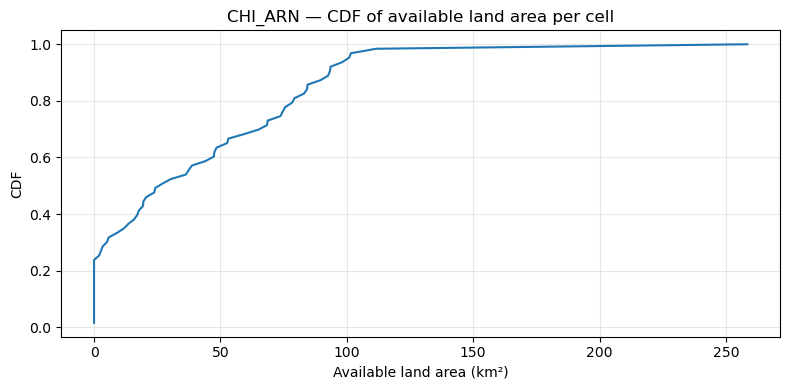

In [6]:
import matplotlib.pyplot as plt

print(attributes_df.describe())
print(f"\nCells with H2 demand > 0: {(attributes_df['avg_h2_demand_MWh'] > 0).sum()} / {len(attributes_df)}")

# CDF of available land area
sorted_land = np.sort(attributes_df['available_land_area_km2'])
cdf = np.arange(1, len(sorted_land) + 1) / len(sorted_land)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sorted_land, cdf)
ax.set_xlabel('Available land area (km²)')
ax.set_ylabel('CDF')
ax.set_title(f'{IDENTIFIER} — CDF of available land area per cell')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

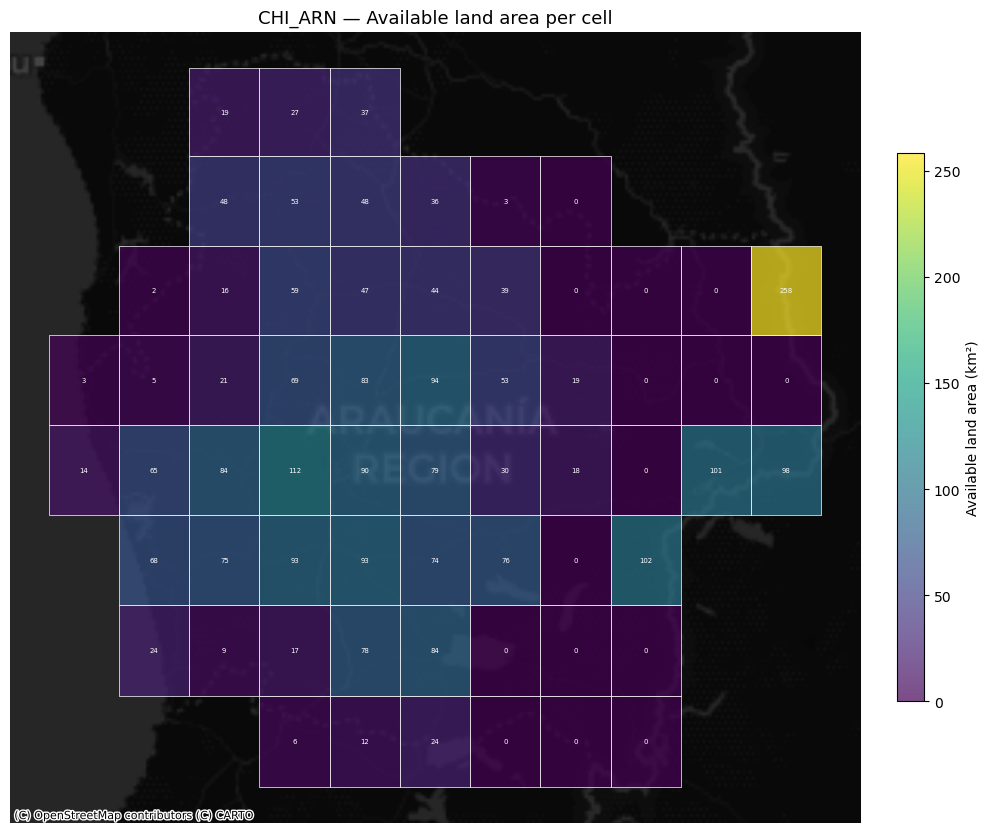

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm
from shapely.geometry import box

# Rebuild cell box geometries from lat/lon
gdf_land = gpd.GeoDataFrame(
    attributes_df[['lon', 'lat', 'available_land_area_km2']].copy(),
    geometry=[box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
              for lon, lat in zip(attributes_df['lon'], attributes_df['lat'])],
    crs="EPSG:4326"
).to_crs(epsg=3857)

norm = Normalize(vmin=0, vmax=gdf_land['available_land_area_km2'].max())
cmap = cm.viridis
transparent_cmap_arr = cmap(np.linspace(0, 1, 256))
transparent_cmap_arr[:, 3] = 0.7
transparent_cmap = cm.colors.ListedColormap(transparent_cmap_arr)

fig, ax = plt.subplots(figsize=(10, 12))
gdf_land.plot(ax=ax, column='available_land_area_km2', cmap=transparent_cmap,
              norm=norm, edgecolor='white', linewidth=0.5)

for _, row in gdf_land.iterrows():
    ax.annotate(
        text=f"{row['available_land_area_km2']:.0f}",
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', va='center', fontsize=5, color='white'
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter, zoom=7)

sm = cm.ScalarMappable(cmap=transparent_cmap, norm=norm)
sm._A = []
fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04).set_label('Available land area (km²)')
ax.set_title(f'{IDENTIFIER} — Available land area per cell', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()